In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [85]:
df=pd.read_csv('ride_fare_dataset.csv')

In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_id                5000 non-null   int64  
 1   pickup_datetime        5000 non-null   str    
 2   hour                   5000 non-null   int64  
 3   day_of_week            5000 non-null   int64  
 4   month                  5000 non-null   int64  
 5   is_weekend             5000 non-null   int64  
 6   is_peak_hour           5000 non-null   int64  
 7   pickup_zone            5000 non-null   str    
 8   dropoff_zone           5000 non-null   str    
 9   trip_distance_km       5000 non-null   float64
 10  trip_duration_minutes  5000 non-null   int64  
 11  passenger_count        5000 non-null   int64  
 12  ride_type              5000 non-null   str    
 13  vehicle_type           5000 non-null   str    
 14  weather                4960 non-null   str    
 15  traffic_level  

In [87]:
df.isnull().sum()

trip_id                   0
pickup_datetime           0
hour                      0
day_of_week               0
month                     0
is_weekend                0
is_peak_hour              0
pickup_zone               0
dropoff_zone              0
trip_distance_km          0
trip_duration_minutes     0
passenger_count           0
ride_type                 0
vehicle_type              0
weather                  40
traffic_level            40
driver_rating             0
surge_multiplier          0
fare                      0
dtype: int64

In [88]:
df.shape

(5000, 19)

In [89]:
df['weather'].unique()

<StringArray>
['Clear', nan, 'Cloudy', 'Rainy', 'Snowy']
Length: 5, dtype: str

In [90]:
df['traffic_level'].unique()

<StringArray>
['Medium', 'Low', 'High', nan, 'Very Heavy']
Length: 5, dtype: str

In [91]:
df['weather'] = df['weather'].fillna(df['weather'].mode()[0])
df['traffic_level'] = df['traffic_level'].fillna(df['traffic_level'].mode()[0])


In [92]:
df.isnull().sum()

trip_id                  0
pickup_datetime          0
hour                     0
day_of_week              0
month                    0
is_weekend               0
is_peak_hour             0
pickup_zone              0
dropoff_zone             0
trip_distance_km         0
trip_duration_minutes    0
passenger_count          0
ride_type                0
vehicle_type             0
weather                  0
traffic_level            0
driver_rating            0
surge_multiplier         0
fare                     0
dtype: int64

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df.nunique()

trip_id                  5000
pickup_datetime          3788
hour                       24
day_of_week                 7
month                      12
is_weekend                  2
is_peak_hour                2
pickup_zone                12
dropoff_zone               12
trip_distance_km         5000
trip_duration_minutes      86
passenger_count             6
ride_type                   5
vehicle_type                4
weather                     4
traffic_level               4
driver_rating              16
surge_multiplier            4
fare                     2918
dtype: int64

In [95]:
df.describe()

,trip_id,hour,day_of_week,month,is_weekend,is_peak_hour,trip_distance_km,trip_duration_minutes,passenger_count,driver_rating,surge_multiplier,fare
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,11.423600,2.991600,6.497000,0.28360,0.332200,13.691787,45.551800,1.555200,4.252340,1.247600,29.789398
std,1443.520003,6.927609,2.000482,3.427235,0.45079,0.471049,6.463912,19.654042,1.049177,0.433368,0.430966,10.805577
min,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,1.146665,5.000000,1.000000,3.500000,1.000000,4.880000
25%,1250.750000,5.000000,1.000000,4.000000,0.00000,0.000000,8.224460,29.000000,1.000000,3.900000,1.000000,21.220000
50%,2500.500000,11.000000,3.000000,7.000000,0.00000,0.000000,13.313862,45.000000,1.000000,4.300000,1.000000,29.550000
75%,3750.250000,17.000000,5.000000,9.000000,1.00000,1.000000,19.283289,62.000000,2.000000,4.600000,1.500000,37.950000
max,5000.000000,23.000000,6.000000,12.000000,1.00000,1.000000,26.984037,92.000000,6.000000,5.000000,2.500000,64.080000


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_id                5000 non-null   int64  
 1   pickup_datetime        5000 non-null   str    
 2   hour                   5000 non-null   int64  
 3   day_of_week            5000 non-null   int64  
 4   month                  5000 non-null   int64  
 5   is_weekend             5000 non-null   int64  
 6   is_peak_hour           5000 non-null   int64  
 7   pickup_zone            5000 non-null   str    
 8   dropoff_zone           5000 non-null   str    
 9   trip_distance_km       5000 non-null   float64
 10  trip_duration_minutes  5000 non-null   int64  
 11  passenger_count        5000 non-null   int64  
 12  ride_type              5000 non-null   str    
 13  vehicle_type           5000 non-null   str    
 14  weather                5000 non-null   str    
 15  traffic_level  

In [97]:
print("Categories in 'pickup_zone' variable: ",end=" ")
print(df['pickup_zone'].unique())

print("Categories in 'dropoff_zone' variable: ",end=" ")
print(df['dropoff_zone'].unique())

print("Categories in 'ride_type' variable: ",end=" ")
print(df['ride_type'].unique())

print("Categories in 'vehicle_type' variable: ",end=" ")
print(df['vehicle_type'].unique())

print("Categories in 'weather' variable: ",end=" ")
print(df['weather'].unique())

print("Categories in 'traffic_level' variable: ",end=" ")
print(df['traffic_level'].unique())

Categories in 'pickup_zone' variable:  <StringArray>
[        'Upper West',          'Chinatown',            'Midtown',
             'Queens', 'Financial District',       'East Village',
           'Brooklyn',               'Soho',           'Downtown',
    'Lower East Side',         'Upper East',            'Tribeca']
Length: 12, dtype: str
Categories in 'dropoff_zone' variable:  <StringArray>
[      'East Village',          'Chinatown',            'Midtown',
               'Soho',             'Queens',           'Downtown',
           'Brooklyn',    'Lower East Side',         'Upper West',
 'Financial District',            'Tribeca',         'Upper East']
Length: 12, dtype: str
Categories in 'ride_type' variable:  <StringArray>
['UberX', 'LyftPlus', 'UberXL', 'Standard', 'Lyft']
Length: 5, dtype: str
Categories in 'vehicle_type' variable:  <StringArray>
['Hatchback', 'SUV', 'Sedan', 'Van']
Length: 4, dtype: str
Categories in 'weather' variable:  <StringArray>
['Clear', 'Cloudy', 'Rai

In [98]:
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features=[feature for feature in df.columns if df[feature].dtype == 'str']

print('We have {0} numerical_features:{1}'.format(len(numerical_features),numerical_features))
print('We have {0} categorical_features:{1}'.format(len(categorical_features),categorical_features))

We have 12 numerical_features:['trip_id', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'trip_distance_km', 'trip_duration_minutes', 'passenger_count', 'driver_rating', 'surge_multiplier', 'fare']
We have 7 categorical_features:['pickup_datetime', 'pickup_zone', 'dropoff_zone', 'ride_type', 'vehicle_type', 'weather', 'traffic_level']


In [99]:
df.head()

,trip_id,pickup_datetime,hour,day_of_week,month,is_weekend,is_peak_hour,pickup_zone,dropoff_zone,trip_distance_km,trip_duration_minutes,passenger_count,ride_type,vehicle_type,weather,traffic_level,driver_rating,surge_multiplier,fare
0,1,30-10-2023 22:00,22,0,10,0,0,Upper West,East Village,11.902094,40,1,UberX,Hatchback,Clear,Medium,4.4,1.0,23.53
1,2,05-02-2023 20:00,20,6,2,1,1,Chinatown,Chinatown,22.562023,71,1,LyftPlus,SUV,Clear,Medium,4.5,2.5,55.94
2,3,13-08-2023 14:00,14,6,8,1,0,Midtown,Midtown,10.355448,33,3,UberX,Sedan,Clear,Medium,4.4,2.0,31.34
3,4,05-08-2023 07:00,7,5,8,1,1,Queens,Soho,22.162918,75,1,UberX,SUV,Cloudy,Low,4.3,1.0,34.82
4,5,27-08-2023 22:00,22,6,8,1,0,Financial District,Queens,22.825534,71,1,UberX,Van,Clear,Medium,3.8,1.0,38.85


In [100]:
df1= df.copy()

In [101]:
df.drop(['trip_id', 'pickup_datetime', 'hour','day_of_week','month','pickup_zone','dropoff_zone','driver_rating'], axis=1, inplace=True)

In [102]:
df.head()

,is_weekend,is_peak_hour,trip_distance_km,trip_duration_minutes,passenger_count,ride_type,vehicle_type,weather,traffic_level,surge_multiplier,fare
0,0,0,11.902094,40,1,UberX,Hatchback,Clear,Medium,1.0,23.53
1,1,1,22.562023,71,1,LyftPlus,SUV,Clear,Medium,2.5,55.94
2,1,0,10.355448,33,3,UberX,Sedan,Clear,Medium,2.0,31.34
3,1,1,22.162918,75,1,UberX,SUV,Cloudy,Low,1.0,34.82
4,1,0,22.825534,71,1,UberX,Van,Clear,Medium,1.0,38.85


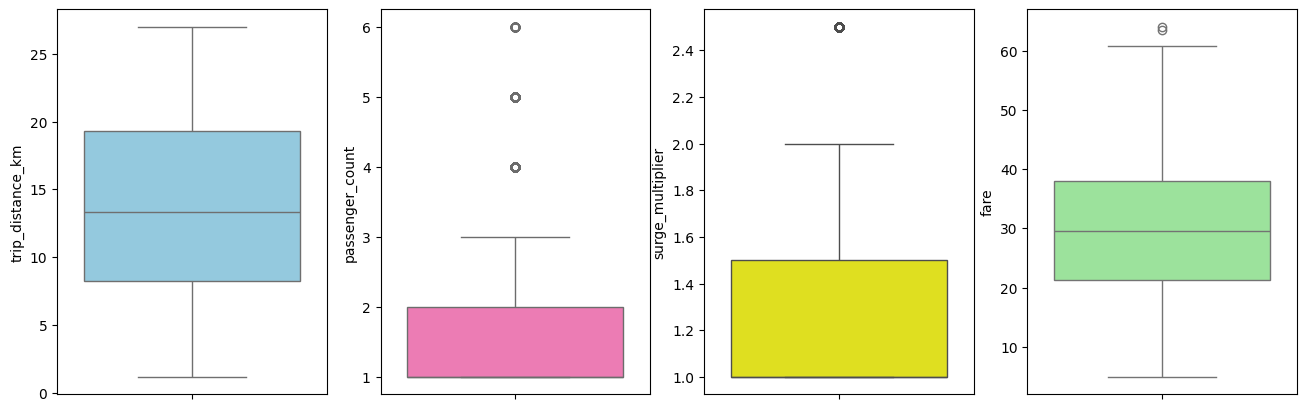

In [103]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['trip_distance_km'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['passenger_count'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['surge_multiplier'],color='yellow')
plt.subplot(144)
sns.boxplot(df['fare'],color='lightgreen')
plt.show()

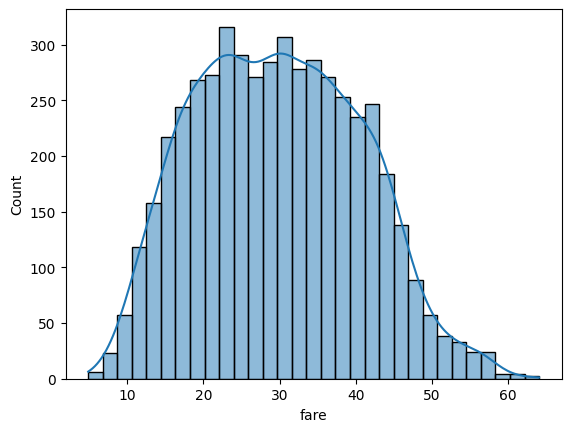

In [104]:
sns.histplot(df['fare'], kde=True)
plt.show()

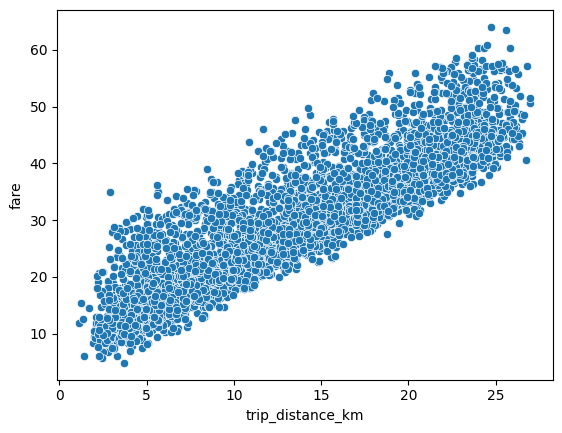

In [105]:
sns.scatterplot(x=df['trip_distance_km'], y=df['fare'])
plt.show()

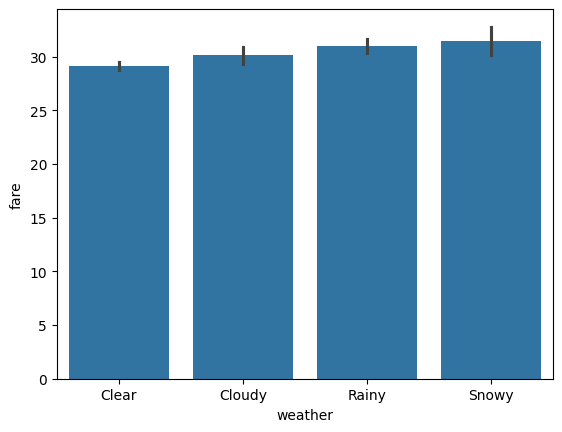

In [106]:
sns.barplot(x='weather', y='fare', data=df)
plt.show()

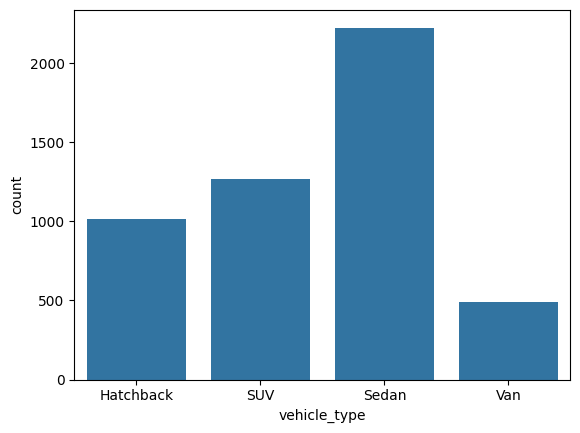

In [107]:
sns.countplot(x='vehicle_type', data=df)
plt.show()

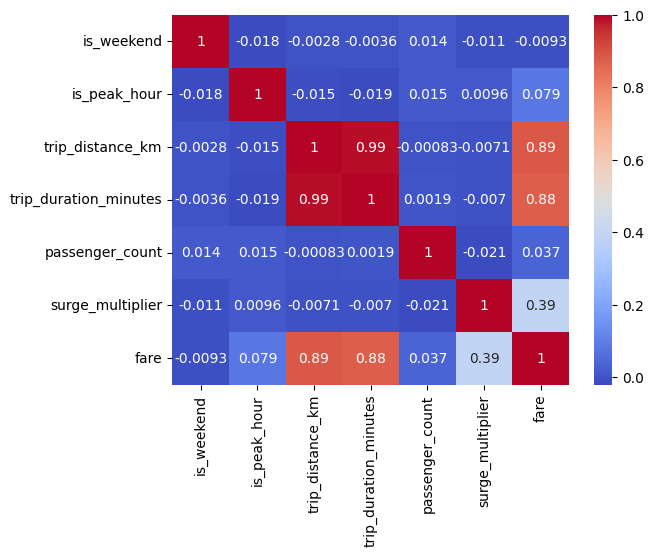

In [108]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [109]:
df.drop('trip_duration_minutes', axis=1, inplace=True)

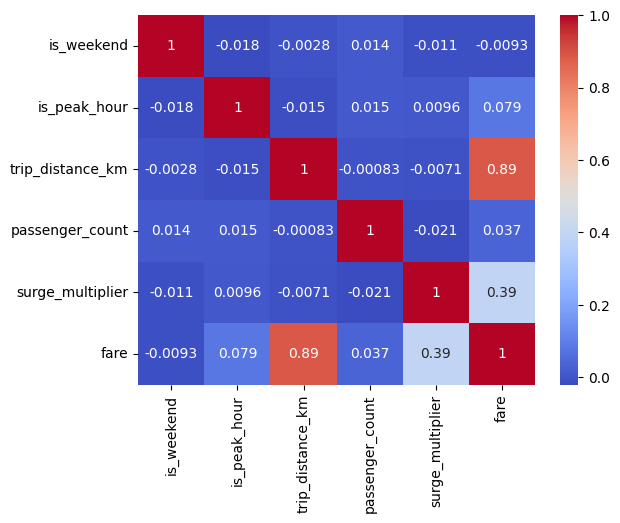

In [110]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [111]:
df.to_csv("ride_fare_clean.csv", index=False)